##Twitter Data Analysis

#Import requireed python libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Loading the dataset

In [2]:
df=pd.read_csv('/content/Twitter_Data.csv')

In [3]:
df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [5]:
df.isnull().sum()

,0
clean_text,4
category,7


#Handling missing values

In [6]:
df=df.dropna()

In [8]:
print(df.isnull().sum())

clean_text    0
category      0
dtype: int64


In [9]:
print(df.shape)

(162969, 2)


In [11]:
df['category'].value_counts()

,count
category,
1.0,72249
0.0,55211
-1.0,35509


#Visualization of Distribution of Sentiments

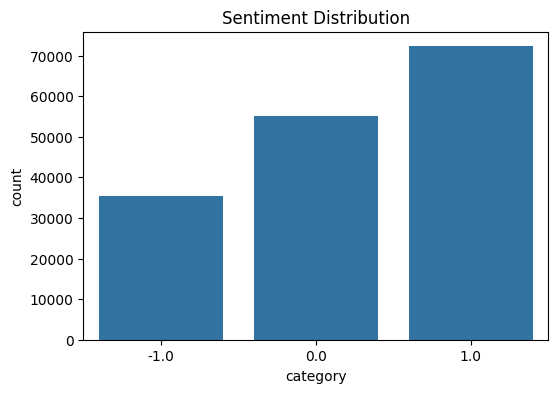

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='category', data=df)

plt.title("Sentiment Distribution")
plt.show()

#Input and output

In [13]:
X = df['clean_text']
y = df['category']

#Creating TF-IDF Features

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X = tfidf.fit_transform(X)

print(X.shape)

(162969, 5000)


#Spliting the data into training and testing

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(130375, 5000)
(32594, 5000)


#Building the model using logistic Regression

In [17]:
from sklearn.linear_model import LogisticRegression
model =LogisticRegression(max_iter=1000)

model.fit(X_train,Y_train)


LogisticRegression(max_iter=1000)

In [20]:
y_pred=model.predict(X_test)
print(y_pred)

[ 0.  1. -1. ...  0.  1.  1.]


#Evaluating the model

In [21]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(Y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(Y_test, y_pred))

Accuracy: 0.8553107933975578

Classification Report:
              precision    recall  f1-score   support

        -1.0       0.86      0.75      0.80      7152
         0.0       0.81      0.95      0.88     11067
         1.0       0.90      0.83      0.86     14375

    accuracy                           0.86     32594
   macro avg       0.86      0.84      0.85     32594
weighted avg       0.86      0.86      0.85     32594



#Visualizing the confusion matrix

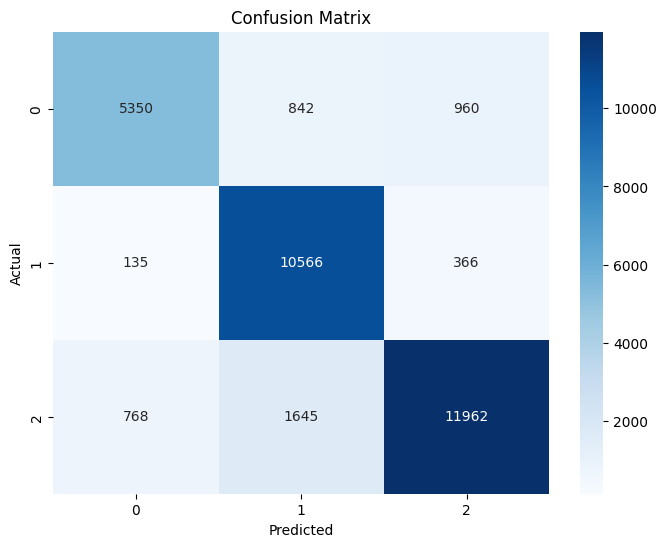

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#Dataset 2


#Play Store: Sentiment Analysis of User Reviews

##Loading the dataset

In [29]:
df=pd.read_csv('/content/user_reviews.csv')

In [30]:
df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [32]:
df.isnull().sum()

,0
App,0
Translated_Review,26868
Sentiment,26863
Sentiment_Polarity,26863
Sentiment_Subjectivity,26863


In [33]:
df = df.dropna(subset=['Translated_Review', 'Sentiment'])

In [34]:
df.isnull().sum()

,0
App,0
Translated_Review,0
Sentiment,0
Sentiment_Polarity,0
Sentiment_Subjectivity,0


In [35]:
print(df['Sentiment'].value_counts())

Sentiment
Positive    23998
Negative     8271
Neutral      5158
Name: count, dtype: int64


##visualizing the distribution of sentiments

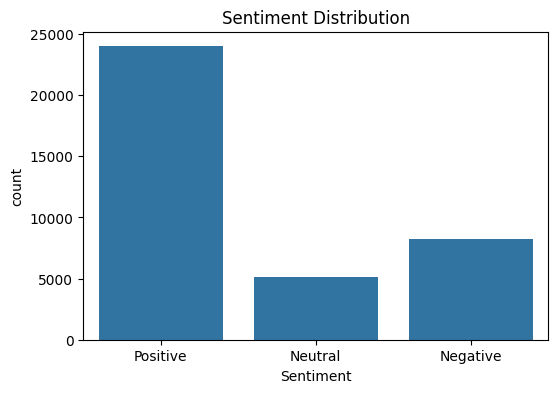

In [36]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sentiment', data=df)

plt.title("Sentiment Distribution")
plt.show()

##Checking for the duplicates

In [38]:
df.duplicated().sum()

np.int64(7735)

##Droping the duplicates

In [39]:
df = df.drop_duplicates()

In [40]:
df.isnull().sum()

,0
App,0
Translated_Review,0
Sentiment,0
Sentiment_Polarity,0
Sentiment_Subjectivity,0


#Input and Output

Sentiment_Polarity and Sentiment_Subjectivity are related to the sentiments ,If we use them in input data leakage may occur for this reason I'm not using this two features in model training

In [41]:
X = df['Translated_Review']
y = df['Sentiment']

#Creating TF-IDF Features

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['Translated_Review']
y = df['Sentiment']

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X = tfidf.fit_transform(X)

print(X.shape)

(29692, 5000)


#Spliting Dataset

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (23753, 5000)
Testing: (5939, 5000)


In [44]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, Y_train)



LogisticRegression(max_iter=1000)

##Building the model  

In [45]:
lr_pred = lr.predict(X_test)

##checking the accuracy of the model
and I got 87% accuracy

In [46]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:",
      accuracy_score(Y_test, lr_pred))

Logistic Regression Accuracy: 0.8755682774877925


##Visualization of confusion matrix

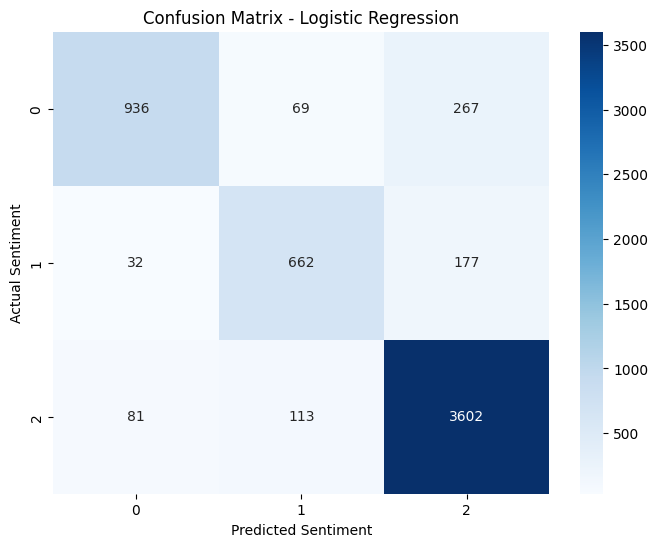

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, lr_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.show()